# **Examen primer parcial**

**Instrucciones:**
- Este examen utiliza el método del caso para evaluar tu comprensión de los KPIs y su rol en la toma de decisiones. 
- En cada pregunta, _explica claramente tu razonamiento_ y muestra todos los cálculos necesarios.
- Utiliza Python (Pandas, Matplotlib, Seaborn) para los cálculos y visualizaciones.
- Sé conciso y directo en tus explicaciones.

----
## **Estudio de Caso: Gabu**

Gabu, una empresa de suscripción digital, que cuida a los niños en su sesión de juegos en linea, está buscando mejorar su rentabilidad y fidelización de clientes. Para ello, debe entender el comportamiento de los usuarios y determinar estrategias para reducir la rotación (churn).

La empresa te proporciona los siguientes datos por cliente:

- customer_id: ID del cliente, padre o tutor del niño.
- kid_id: ID del niño.
- kids_age: Edad del niño.
- kids_sex: Sexo del niño. 0 niño, 1 niña.
- family_income: Ingreso anual de la familia
- subscription_type: Tipo de suscripción (Básica, Premium, Familiar).
- monthly_fee: Tarifa mensual pagada por el usuario en USD. En el plan familiar se cobra $35 USD por toda la familia.
- avg_session_time: Promedio de tiempo de sesión en minutos.
- customer_support_tickets: Tickets de soporte abiertos por el cliente.
- issue_resolution_time: Tiempo promedio de resolución de tickets en horas.
- tenure: Meses que han pasado desde que el niño se unió a Gabu.
- signup_channel: Canal de adquisición del padre o tutor.
- total_sessions: Número total de sesiones en la plataforma.
- churn: 1 si el cliente canceló su suscripción, 0 si sigue activo.

La empresa quiere saber qué factores afectan la cancelación de clientes y cómo mejorar la rentabilidad.

----

## **Sección 1: Limpieza de Datos (25 pts)**  

1. ¿Existen valores atípicos (nulos y outliers) en el dataset?
   - Identifica con Rango intercuartil con factor de 1.5 los outliers presentes en las columnas kids_age, family_income y avg_session_time.
   - Identifica los valores nulos en las columnas family_income, monthly_fee y avg_session_time.
2. Decide qué hacer con los datos atípicos:  
   - Eliminarlos o imputarlos.
   - Justifica tu decisión con base en la información disponible.
3. Implementa tu decisión.

In [63]:
import pandas as pd

df = pd.read_csv("/Users/carloskelly/Documents/iteso/analisis-datos-diseno-indicadores/02-evaluacion-madurez-analitica-y-elaboracion-reportes-ejecutivos/data/gabu_dataset.csv")
df

,customer_id,kid_id,kids_age,kids_sex,family_income,subscription_type,monthly_fee,avg_session_time,customer_support_tickets,issue_resolution_time,tenure,signup_channel,total_sessions,churn
0,1,1_1,6,0,75000.0,Premium,20.000000,NaN,3,7.345257,25,Referral,125,0
1,2,2_1,12,0,50000.0,Familiar,11.666667,34.791037,2,1.972350,13,Social Media,65,0
2,2,2_2,11,0,50000.0,Familiar,11.666667,36.265145,2,6.236660,8,Social Media,40,0
3,2,2_3,8,0,50000.0,Familiar,11.666667,32.497897,2,3.767872,18,Social Media,180,0
4,3,3_1,7,1,50000.0,Familiar,17.500000,24.088886,2,6.342374,7,Ads,56,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1312,944,944_1,11,0,75000.0,Familiar,17.500000,27.391241,1,6.489045,8,Referral,72,0
1313,944,944_2,6,0,75000.0,Familiar,17.500000,38.753474,1,3.238959,25,Referral,275,0
1314,945,945_1,11,0,25000.0,Premium,20.000000,14.326851,3,6.894745,1,Ads,11,0
1315,946,946_1,11,0,75000.0,Premium,20.000000,32.887024,3,6.727515,12,Organic,48,1


## 1.1

### Nulos

In [68]:
null_vars = ["family_income", "monthly_fee", "avg_session_time"]

print("\nNumero")
print(df[null_vars].isna().sum())


print("\nPorcentaje")
print(df[null_vars].isna().mean())


Numero
family_income       10
monthly_fee          5
avg_session_time    10
dtype: int64

Porcentaje
family_income       0.007593
monthly_fee         0.003797
avg_session_time    0.007593
dtype: float64


### Outliers

In [84]:
outlier_vars = ["kids_age", "family_income", "avg_session_time"]

def iqr_bounds(df, col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    min = 1.5*iqr - q1
    max = 1.5*iqr + q3
    return min, max


print(outlier_vars[0])
print(iqr_bounds(df, outlier_vars[0]))
print(((df[outlier_vars[0]] < iqr_bounds(df, outlier_vars[0])[0]) | (df[outlier_vars[0]] > iqr_bounds(df, outlier_vars[0])[1])).mean())

print(outlier_vars[1])
print(iqr_bounds(df, outlier_vars[1]))
print(((df[outlier_vars[1]] < iqr_bounds(df, outlier_vars[1])[0]) | (df[outlier_vars[1]] > iqr_bounds(df, outlier_vars[1])[1])).mean())

print(outlier_vars[2])
print(iqr_bounds(df, outlier_vars[2]))
print(((df[outlier_vars[2]] < iqr_bounds(df, outlier_vars[2])[0]) | (df[outlier_vars[2]] > iqr_bounds(df, outlier_vars[2])[1])).mean())


kids_age
(-1.0, 17.0)
0.002277904328018223
family_income
(25000.0, 175000.0)
0.05011389521640091
avg_session_time
(-4.495038643614997, 62.5683297828136)
0.0037965072133637054


In [82]:
((df[outlier_vars[0]] < iqr_bounds(df, outlier_vars[0])[0]) |  \
    (df[outlier_vars[0]] > iqr_bounds(df, outlier_vars[0])[1])).mean()

0.002277904328018223

## 1.2

En nulos tengo que imputar datos dado que es menor al 20%. 
En outliers lo que tengo que hacer es eliminarlos.

## 1.3


### Nulos

In [ ]:
df["family_income"] = df["family_income"].fillna(df["family_income"].median())
df["monthly_fee"] = df["monthly_fee"].fillna(df["monthly_fee"].median())
df["avg_session_time"] = df["avg_session_time"].fillna(df["avg_session_time"].median())

### Outliers

In [86]:
outlier_vars = ["kids_age", "family_income", "avg_session_time"]

kids_age_filter =  (df[outlier_vars[0]] >= iqr_bounds(df, outlier_vars[0])[0]) & \
    (df[outlier_vars[0]] <= iqr_bounds(df, outlier_vars[0])[1])
family_income_filter =  (df[outlier_vars[1]] >= iqr_bounds(df, outlier_vars[1])[0]) & \
    (df[outlier_vars[1]] <= iqr_bounds(df, outlier_vars[1])[1])
avg_session_time_filter =  (df[outlier_vars[2]] >= iqr_bounds(df, outlier_vars[2])[0]) & \
    (df[outlier_vars[2]] <= iqr_bounds(df, outlier_vars[2])[1])

In [92]:
filters = (kids_age_filter) & (family_income_filter) & (avg_session_time_filter)
filters.mean()

0.9301442672741078

In [94]:
df_clean = df[filters]
df_clean

,customer_id,kid_id,kids_age,kids_sex,family_income,subscription_type,monthly_fee,avg_session_time,customer_support_tickets,issue_resolution_time,tenure,signup_channel,total_sessions,churn
1,2,2_1,12,0,50000.0,Familiar,11.666667,34.791037,2,1.972350,13,Social Media,65,0
2,2,2_2,11,0,50000.0,Familiar,11.666667,36.265145,2,6.236660,8,Social Media,40,0
3,2,2_3,8,0,50000.0,Familiar,11.666667,32.497897,2,3.767872,18,Social Media,180,0
4,3,3_1,7,1,50000.0,Familiar,17.500000,24.088886,2,6.342374,7,Ads,56,1
5,3,3_2,9,0,50000.0,Familiar,17.500000,24.260828,2,3.714115,4,Ads,24,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1312,944,944_1,11,0,75000.0,Familiar,17.500000,27.391241,1,6.489045,8,Referral,72,0
1313,944,944_2,6,0,75000.0,Familiar,17.500000,38.753474,1,3.238959,25,Referral,275,0
1314,945,945_1,11,0,25000.0,Premium,20.000000,14.326851,3,6.894745,1,Ads,11,0
1315,946,946_1,11,0,75000.0,Premium,20.000000,32.887024,3,6.727515,12,Organic,48,1


----
## **Sección 2: Análisis de Rentabilidad y Churn (25 pts)**  

1. Calcula el **ARPK** (Average Revenue Per Kid):  
    ARPK = $\frac{\sum \text{Monthly Fee}}{\text{Número total de niños activos}}$

2. Calcula la **tasa de churn** como:  
   Churn Rate = $\frac{\text{Clientes que cancelaron}}{\text{Clientes totales}}$

3. Caulcula la columna avg_sessions_per_month. El objetivo de esta columna es entender cuantas veces asistía al mes en promedio cada niño.

3. Realiza **dos visualizaciones** de gráfica de barras:  
   - Visualiza la distribución del ARPK por canal de adquisición.
   - Visualiza la distribución del Churn por tipo de suscripción.

4. ¿Qué observas en ambas gráficas? ¿Cuáles son tus conclusiones? 

## 1. ARPK

In [95]:
df_clean["monthly_fee"].sum() / (1-df_clean["churn"]).sum()

22.710867802108677

In [96]:
df_clean["monthly_fee"].mean()

15.289380289380288

## 2. Churn

In [97]:
df_clean["churn"].mean()

0.3289795918367347

## 3. Avg sessions per month

In [ ]:
df_clean["avg_sessions_per_month"] = df_clean["total_sessions"] / df_clean["tenure"]

## 4. Graphs

  signup_channel          0
0            Ads  21.267986
1        Organic  23.766667
2       Referral  24.321625
3   Social Media  20.751634


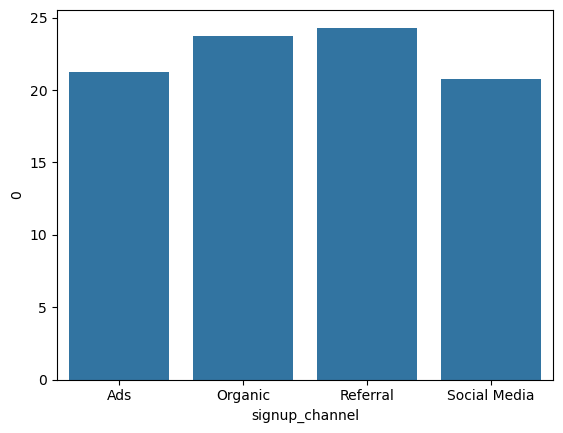

In [107]:
import seaborn as sns
import matplotlib.pyplot as plt

arpk_signup_channel = (df_clean.groupby("signup_channel")["monthly_fee"].sum() / (df_clean.groupby("signup_channel")["churn"].count() - df_clean.groupby("signup_channel")["churn"].sum())).reset_index()

print(arpk_signup_channel)
sns.barplot(data=arpk_signup_channel, x="signup_channel", y=0)
plt.show()

  subscription_type     churn
0            Básica  0.558719
1          Familiar  0.207770
2           Premium  0.349432


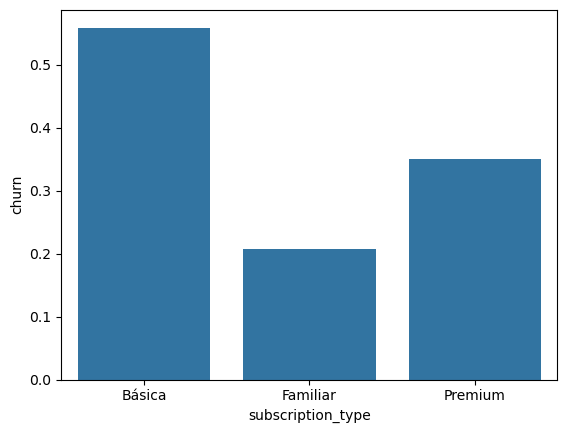

In [110]:
churn_rate_per_signup = df_clean.groupby("subscription_type")["churn"].mean().reset_index()

print(churn_rate_per_signup)
sns.barplot(data=churn_rate_per_signup, x="subscription_type", y="churn")
plt.show()

----
## **Sección 3: Factores de Churn y Estrategias (25 pts)**  

1. Calcula la **matriz de correlación** para todas las variables.  
2. Identifica las tres variables más correlacionadas con el **churn**. Visualiza la relación entre las variables e interpreta los resultados:
   - ¿Qué patrones observas en los clientes que cancelan su suscripción?
3. Observa la relación entre churn y las variables categóricas del dataset.
   - ¿Qué patrones observas en los clientes que cancelan su suscripción?
4. Propón **dos estrategias** para reducir la tasa de churn basadas en el análisis. 

In [112]:
df_clean.corr(numeric_only=True)["churn"]

customer_id                 0.031110
kids_age                   -0.025936
kids_sex                    0.033127
family_income               0.016363
monthly_fee                -0.108111
avg_session_time           -0.119425
customer_support_tickets    0.236443
issue_resolution_time       0.169145
tenure                     -0.167988
total_sessions             -0.130423
churn                       1.000000
Name: churn, dtype: float64

<Axes: xlabel='churn', ylabel='customer_support_tickets'>

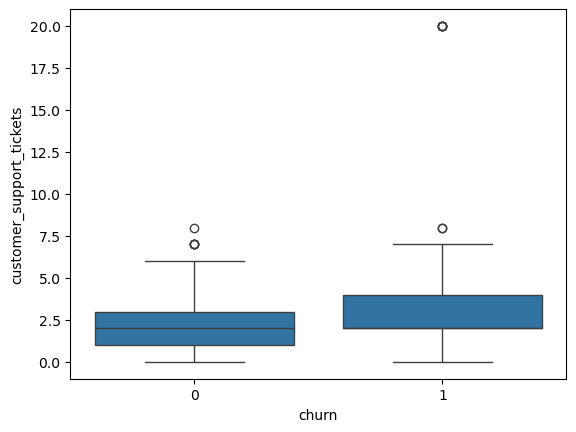

In [113]:
sns.boxplot(data=df_clean, x="churn", y="customer_support_tickets")

<Axes: xlabel='churn', ylabel='issue_resolution_time'>

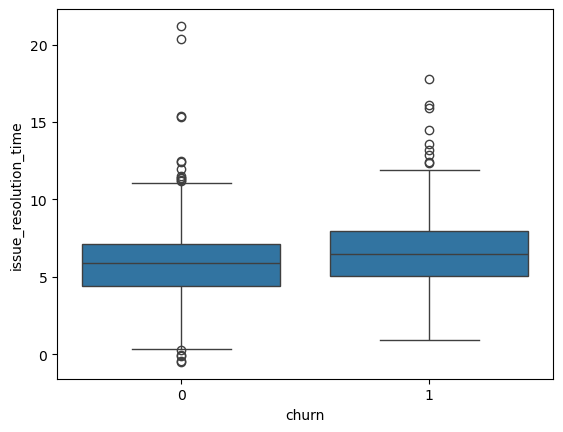

In [114]:
sns.boxplot(data=df_clean, x="churn", y="issue_resolution_time")

<Axes: xlabel='churn', ylabel='tenure'>

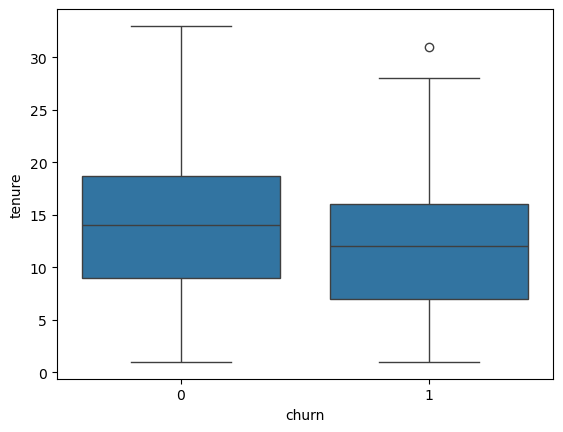

In [115]:
sns.boxplot(data=df_clean, x="churn", y="tenure")

---

## **Sección 4: Mejora de Rentabilidad en LTV (25 pts)**  
1. Calcula el LTV. 
   - LTV = $Monthly fee \times \text{Tenure}$
2. Identifica las tres variables más correlacionadas con el **LTV**. Visualiza la relación entre las variables e interpreta los resultados:  
   - ¿Qué patrones observas en los clientes con mayor y menor LTV? 
3. Observa la relación entre LTV y las variables categóricas del dataset.
   - ¿Qué patrones observas en los clientes con mayor y menor LTV?
4. Propón **dos estrategias** para aumentar el LTV basadas en el análisis.

In [116]:
df_clean["ltv"] = df_clean["monthly_fee"] * df_clean["tenure"]

df_clean.corr(numeric_only=True)["ltv"]

/var/folders/p_/t355wf8d61177pp2l7_8j9480000gn/T/ipykernel_61959/1667606865.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["ltv"] = df_clean["monthly_fee"] * df_clean["tenure"]


customer_id                 0.001423
kids_age                   -0.003224
kids_sex                   -0.234212
family_income               0.078894
monthly_fee                 0.459425
avg_session_time            0.701267
customer_support_tickets   -0.280914
issue_resolution_time      -0.143989
tenure                      0.841839
total_sessions              0.675837
churn                      -0.198102
ltv                         1.000000
Name: ltv, dtype: float64

<Axes: xlabel='total_sessions', ylabel='ltv'>

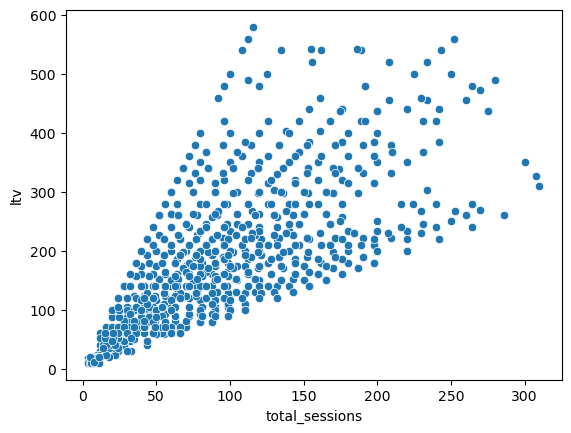

In [117]:
sns.scatterplot(data=df_clean, x="total_sessions", y="ltv")

<Axes: xlabel='customer_support_tickets', ylabel='ltv'>

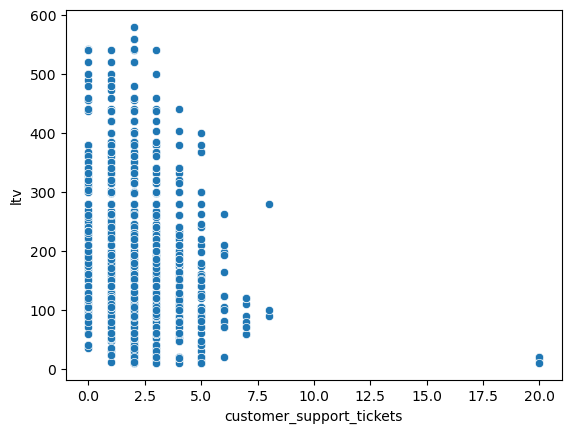

In [120]:
sns.scatterplot(data=df_clean, x="customer_support_tickets", y="ltv")

<Axes: xlabel='avg_session_time', ylabel='ltv'>

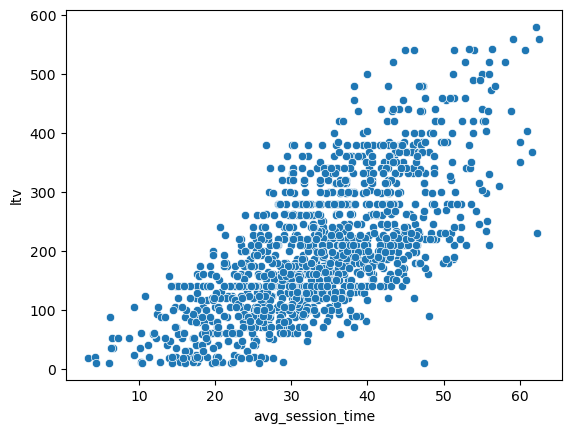

In [121]:
sns.scatterplot(data=df_clean, x="avg_session_time", y="ltv")